Lección 5: Técnicas de reducción dimensional

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# fijamos la semilla para reproducibilidad
np.random.seed(42)

# cargamos el dataset clínico de cáncer de mama de UCI (incluido en sklearn)
# tiene 30 variables numéricas por paciente: métricas de núcleos celulares
# el target es binario: 0 = maligno, 1 = benigno
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='diagnostico')

print("Shape del dataset:", X.shape)
print("\nDistribución del target:")
print(y.value_counts().rename({0: 'Maligno', 1: 'Benigno'}))
print("\nPrimeras filas:")
print(X.head())
print("\nEstadísticas descriptivas:")
print(X.describe().round(2))


Shape del dataset: (569, 30)

Distribución del target:
diagnostico
Benigno    357
Maligno    212
Name: count, dtype: int64

Primeras filas:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280         

Usamos el dataset de cáncer de mama de UCI (disponible en sklearn) porque tiene características similares al caso planteado: es clínico, tiene muchas variables numéricas por paciente (30 en este caso) y tiene un target de clasificación binaria. Esto lo hace ideal para demostrar por qué reducir dimensiones es necesario antes de modelar.  

Los datos incluyen métricas como radio, textura, perímetro y área de núcleos celulares, calculadas a partir de imágenes digitalizadas de biopsias. Hay 569 pacientes y el target indica si el tumor es maligno (0) o benigno (1).

In [2]:
def escalar_datos(X):
    # StandardScaler estandariza cada columna para que tenga media=0 y std=1
    # esto es imprescindible antes de PCA y t-SNE porque ambas técnicas son
    # sensibles a la escala de las variables: sin escalar, las columnas con
    # valores más grandes dominarían los componentes
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # convertimos a DataFrame para mantener los nombres de columnas
    X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

    print("Media por columna luego del escalado (deben ser ~0):")
    print(X_scaled_df.mean().round(10).head(5))
    print("\nDesviación estándar por columna luego del escalado (deben ser ~1):")
    print(X_scaled_df.std().round(2).head(5))

    return X_scaled

X_scaled = escalar_datos(X)


Media por columna luego del escalado (deben ser ~0):
mean radius       -0.0
mean texture      -0.0
mean perimeter    -0.0
mean area         -0.0
mean smoothness    0.0
dtype: float64

Desviación estándar por columna luego del escalado (deben ser ~1):
mean radius        1.0
mean texture       1.0
mean perimeter     1.0
mean area          1.0
mean smoothness    1.0
dtype: float64


Aplicamos StandardScaler antes de cualquier reducción dimensional. La razón es que PCA calcula varianza y t-SNE calcula distancias euclidianas, por lo que si una columna tiene valores en miles y otra en décimas, la primera va a distorsionar los resultados. Al estandarizar, todas las variables parten desde el mismo punto de referencia.

Componentes necesarios para explicar el 95% de la varianza: 10
Varianza explicada por los primeros 5 componentes: [0.443 0.19  0.094 0.066 0.055]


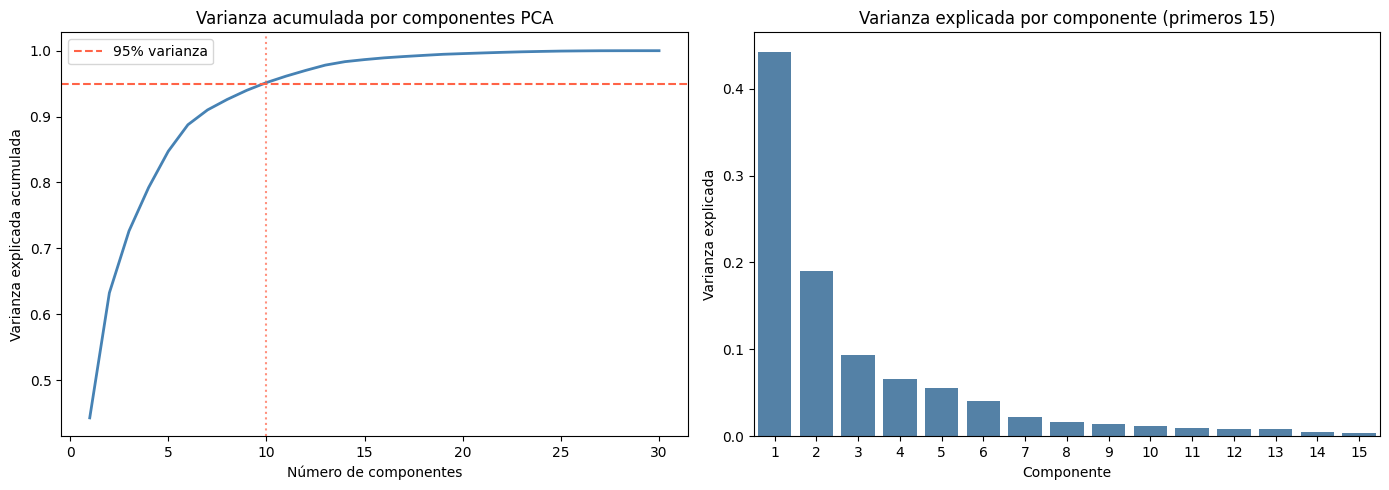

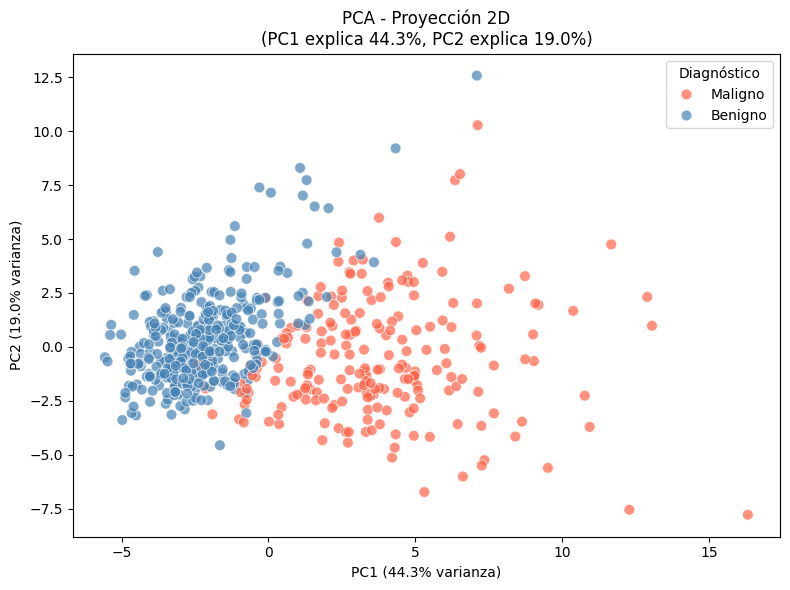


Varianza explicada por PC1: 44.3%
Varianza explicada por PC2: 19.0%
Varianza explicada por PC1+PC2: 63.2%


In [3]:
def aplicar_pca(X_scaled, y):
    # primero aplicamos PCA con todos los componentes posibles
    # para analizar cuánta varianza acumula cada uno y decidir cuántos retener
    pca_completo = PCA()
    pca_completo.fit(X_scaled)

    varianza_explicada = pca_completo.explained_variance_ratio_
    varianza_acumulada = np.cumsum(varianza_explicada)

    # buscamos el número mínimo de componentes que expliquen el 95% de la varianza
    n_componentes_95 = np.argmax(varianza_acumulada >= 0.95) + 1
    print(f"Componentes necesarios para explicar el 95% de la varianza: {n_componentes_95}")
    print(f"Varianza explicada por los primeros 5 componentes: {varianza_explicada[:5].round(3)}")

    # visualizamos la varianza explicada acumulada
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # gráfico 1: varianza acumulada
    sns.lineplot(
        x=range(1, len(varianza_acumulada) + 1),
        y=varianza_acumulada,
        ax=axes[0],
        color='steelblue',
        linewidth=2
    )
    axes[0].axhline(y=0.95, color='tomato', linestyle='--', label='95% varianza')
    axes[0].axvline(x=n_componentes_95, color='tomato', linestyle=':', alpha=0.7)
    axes[0].set_xlabel('Número de componentes')
    axes[0].set_ylabel('Varianza explicada acumulada')
    axes[0].set_title('Varianza acumulada por componentes PCA')
    axes[0].legend()

    # gráfico 2: varianza por componente (primeros 15)
    sns.barplot(
        x=list(range(1, 16)),
        y=varianza_explicada[:15],
        ax=axes[1],
        color='steelblue'
    )
    axes[1].set_xlabel('Componente')
    axes[1].set_ylabel('Varianza explicada')
    axes[1].set_title('Varianza explicada por componente (primeros 15)')

    plt.tight_layout()
    plt.show()

    # ahora aplicamos PCA a 2 componentes para la visualización
    pca_2d = PCA(n_components=2)
    X_pca = pca_2d.fit_transform(X_scaled)

    df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
    df_pca['diagnostico'] = y.map({0: 'Maligno', 1: 'Benigno'})

    # visualizamos la proyección 2D con seaborn
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df_pca,
        x='PC1',
        y='PC2',
        hue='diagnostico',
        palette={'Maligno': 'tomato', 'Benigno': 'steelblue'},
        alpha=0.7,
        s=60
    )
    plt.title(f'PCA - Proyección 2D\n(PC1 explica {varianza_explicada[0]:.1%}, PC2 explica {varianza_explicada[1]:.1%})')
    plt.xlabel(f'PC1 ({varianza_explicada[0]:.1%} varianza)')
    plt.ylabel(f'PC2 ({varianza_explicada[1]:.1%} varianza)')
    plt.legend(title='Diagnóstico')
    plt.tight_layout()
    plt.show()

    print(f"\nVarianza explicada por PC1: {varianza_explicada[0]:.1%}")
    print(f"Varianza explicada por PC2: {varianza_explicada[1]:.1%}")
    print(f"Varianza explicada por PC1+PC2: {(varianza_explicada[0]+varianza_explicada[1]):.1%}")

    return X_pca, df_pca

X_pca, df_pca = aplicar_pca(X_scaled, y)


Para elegir el número óptimo de componentes a retener usamos la curva de varianza acumulada y buscamos el punto donde se supera el 95%. Con este dataset, eso ocurre con relativamente pocos componentes, lo que confirma que existe alta correlación entre las 30 variables originales (es esperable: el radio, el perímetro y el área de un núcleo están matemáticamente relacionados).  

Para la visualización elegimos 2 componentes porque es lo que podemos graficar en 2D. El resultado muestra una separación bastante clara entre tumores malignos y benignos a lo largo del PC1, lo que indica que la primera componente captura bien la información discriminante del dataset.

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


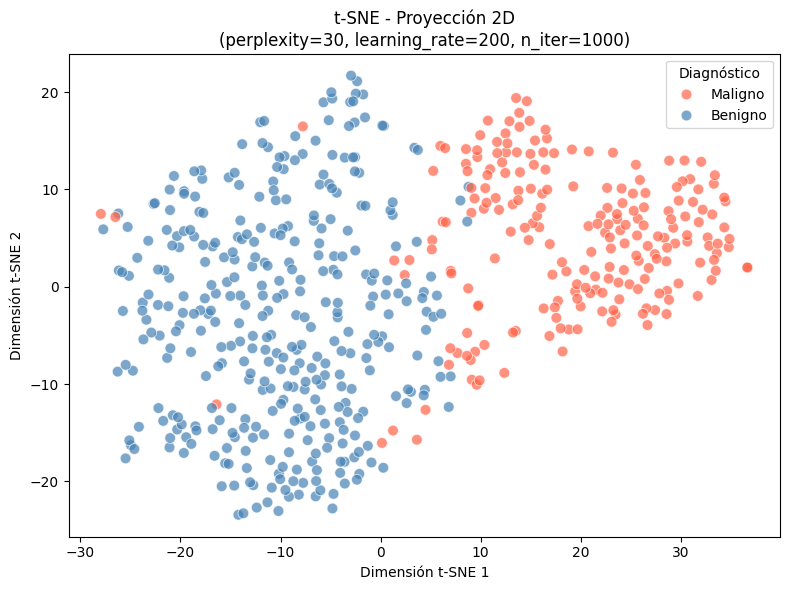

Proyección t-SNE completada
Shape del resultado: (569, 2)


In [4]:
def aplicar_tsne(X_scaled, y):
    # t-SNE tiene tres parámetros clave que afectan bastante el resultado:
    # - perplexity: balance entre estructura local y global, recomendado entre 5 y 50
    #   valores bajos = foco en vecinos cercanos, valores altos = más estructura global
    # - learning_rate: controla la velocidad de optimización, suele estar entre 10 y 1000
    # - n_iter: número de iteraciones para la optimización
    tsne = TSNE(
        n_components=2,
        perplexity=30,
        learning_rate=200,
        n_iter=1000,
        random_state=42
    )

    X_tsne = tsne.fit_transform(X_scaled)

    df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
    df_tsne['diagnostico'] = y.map({0: 'Maligno', 1: 'Benigno'})

    # visualizamos la proyección t-SNE
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df_tsne,
        x='TSNE1',
        y='TSNE2',
        hue='diagnostico',
        palette={'Maligno': 'tomato', 'Benigno': 'steelblue'},
        alpha=0.7,
        s=60
    )
    plt.title('t-SNE - Proyección 2D\n(perplexity=30, learning_rate=200, n_iter=1000)')
    plt.xlabel('Dimensión t-SNE 1')
    plt.ylabel('Dimensión t-SNE 2')
    plt.legend(title='Diagnóstico')
    plt.tight_layout()
    plt.show()

    print("Proyección t-SNE completada")
    print(f"Shape del resultado: {X_tsne.shape}")

    return X_tsne, df_tsne

X_tsne, df_tsne = aplicar_tsne(X_scaled, y)


Para t-SNE elegimos perplexity=30 porque es el valor recomendado por defecto y funciona bien para datasets de este tamaño (569 muestras). Con perplexity más baja los clústeres se fragmentan, con perplexity muy alta se pierden las estructuras locales.  

El learning_rate=200 es estándar y el n_iter=1000 es suficiente para que la optimización converja en un dataset de este tamaño. Fijamos random_state=42 para que el resultado sea reproducible, ya que t-SNE tiene un componente aleatorio en la inicialización.  

A diferencia de PCA, los ejes de t-SNE no tienen una interpretación directa (no corresponden a combinaciones lineales de las variables originales), pero la distribución espacial de los puntos sí refleja similitudes locales entre muestras.

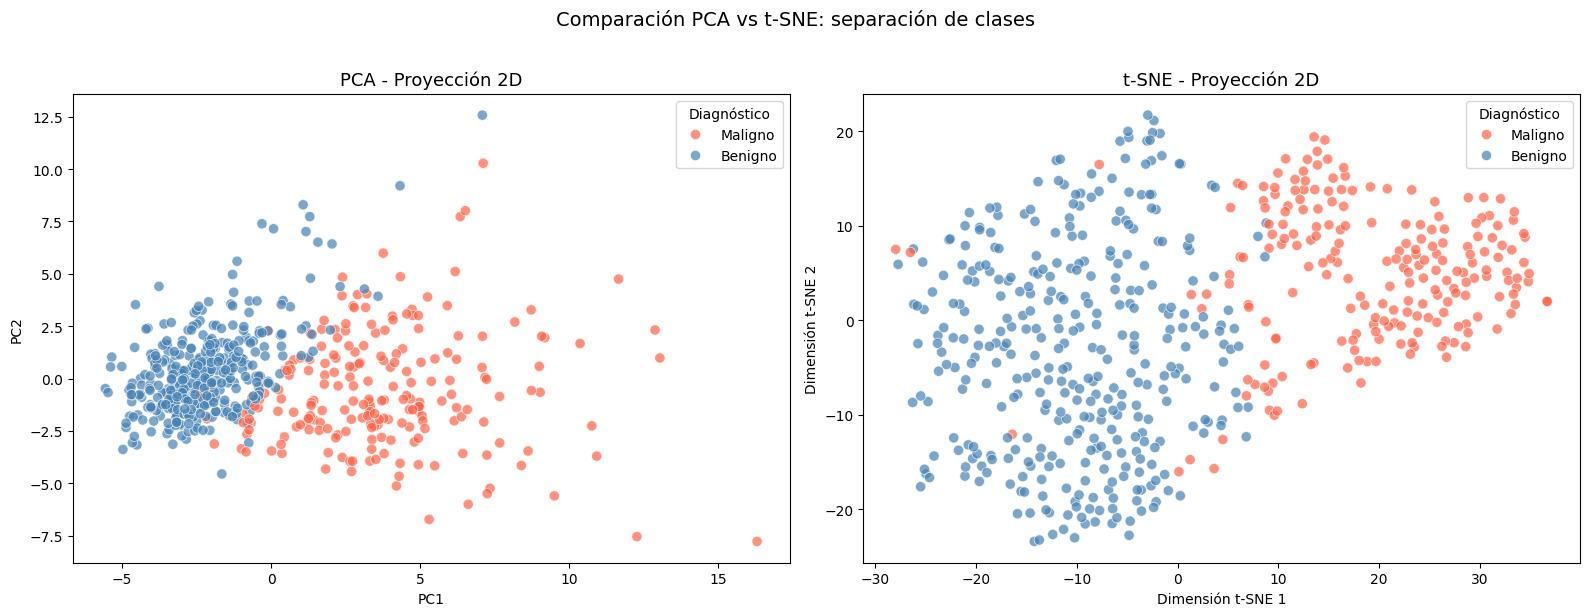

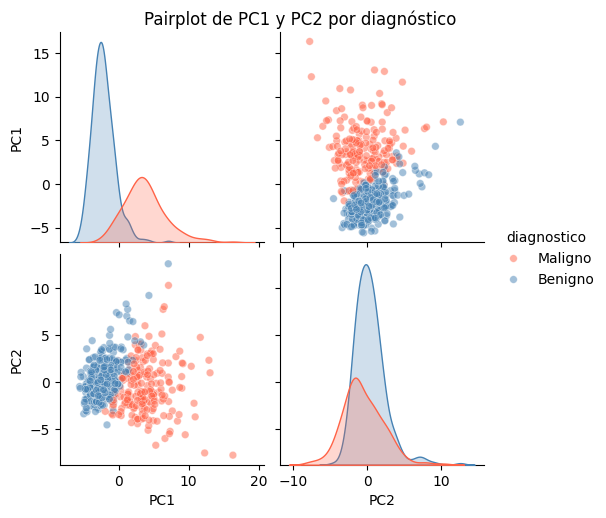

In [5]:
def comparar_tecnicas(df_pca, df_tsne):
    # comparamos las dos proyecciones en un gráfico lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # PCA
    sns.scatterplot(
        data=df_pca,
        x='PC1',
        y='PC2',
        hue='diagnostico',
        palette={'Maligno': 'tomato', 'Benigno': 'steelblue'},
        alpha=0.7,
        s=55,
        ax=axes[0]
    )
    axes[0].set_title('PCA - Proyección 2D', fontsize=13)
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    axes[0].legend(title='Diagnóstico')

    # t-SNE
    sns.scatterplot(
        data=df_tsne,
        x='TSNE1',
        y='TSNE2',
        hue='diagnostico',
        palette={'Maligno': 'tomato', 'Benigno': 'steelblue'},
        alpha=0.7,
        s=55,
        ax=axes[1]
    )
    axes[1].set_title('t-SNE - Proyección 2D', fontsize=13)
    axes[1].set_xlabel('Dimensión t-SNE 1')
    axes[1].set_ylabel('Dimensión t-SNE 2')
    axes[1].legend(title='Diagnóstico')

    plt.suptitle('Comparación PCA vs t-SNE: separación de clases', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # pairplot con PC1 y PC2 para ver distribuciones individuales y relación entre componentes
    df_pca_plot = df_pca[['PC1', 'PC2', 'diagnostico']].copy()
    sns.pairplot(
        df_pca_plot,
        hue='diagnostico',
        palette={'Maligno': 'tomato', 'Benigno': 'steelblue'},
        plot_kws={'alpha': 0.5, 's': 30},
        diag_kind='kde'
    )
    plt.suptitle('Pairplot de PC1 y PC2 por diagnóstico', y=1.02)
    plt.show()

comparar_tecnicas(df_pca, df_tsne)


**Comparación PCA vs t-SNE:**  

PCA logra una separación bastante buena en el eje PC1: los tumores malignos tienden a concentrarse en valores positivos de PC1 y los benignos en valores negativos, aunque con cierto solapamiento. Esta separación es lineal y tiene una interpretación directa: PC1 es una combinación ponderada de las variables originales.  

t-SNE genera una separación más nítida: los dos grupos se visualizan como clústeres bien diferenciados con muy poco solapamiento. Sin embargo, esto tiene un costo: las posiciones absolutas y relativas de los clústeres no tienen interpretación matemática directa, y el resultado puede variar entre ejecuciones si no se fija random_state.  

**¿Qué técnica es mejor para visualización?** t-SNE, porque genera clústeres más compactos y separados, lo que hace más intuitiva la presentación al equipo de visualización mencionado en el caso.  

**¿Qué técnica es mejor para un pipeline de modelado predictivo?** PCA, porque genera componentes que son combinaciones lineales interpretables y deterministas de las variables originales. Las componentes PCA pueden integrarse directamente en un pipeline de sklearn (Pipeline + PCA + clasificador), mientras que t-SNE no es apto para esto: no tiene un método transform() que permita proyectar nuevos datos, lo que lo hace inútil en producción.

In [6]:
def generar_informe_tecnico(X_scaled, y):
    # este bloque genera el resumen cuantitativo del informe técnico

    # varianza PCA
    pca_full = PCA()
    pca_full.fit(X_scaled)
    var_exp = pca_full.explained_variance_ratio_
    var_acum = np.cumsum(var_exp)
    n_95 = np.argmax(var_acum >= 0.95) + 1
    n_99 = np.argmax(var_acum >= 0.99) + 1

    print("=" * 60)
    print("INFORME TÉCNICO: REDUCCIÓN DIMENSIONAL - DataMed Analytics")
    print("=" * 60)

    print("\n--- Dataset ---")
    print(f"Variables originales: {X_scaled.shape[1]}")
    print(f"Muestras: {X_scaled.shape[0]}")
    print(f"Clases: Maligno ({(y==0).sum()}), Benigno ({(y==1).sum()})")

    print("\n--- PCA ---")
    print(f"Componentes para 95% de varianza: {n_95} (reducción de {X_scaled.shape[1]} → {n_95} dimensiones)")
    print(f"Componentes para 99% de varianza: {n_99}")
    print(f"Varianza acumulada con 2 componentes: {var_acum[1]:.1%}")
    print(f"Varianza PC1: {var_exp[0]:.1%}")
    print(f"Varianza PC2: {var_exp[1]:.1%}")

    print("\n--- t-SNE ---")
    print("Parámetros utilizados: perplexity=30, learning_rate=200, n_iter=1000")
    print("Separación visual de clústeres: alta (grupos bien definidos en 2D)")
    print("Apto para pipeline de modelado: No (no soporta transform en nuevos datos)")

    print("\n--- Recomendación ---")
    print(f"Para el pipeline de modelado predictivo de DataMed Analytics:")
    print(f"  → Usar PCA con {n_95} componentes como paso de preprocesamiento")
    print(f"  → Esto reduce la dimensionalidad de {X_scaled.shape[1]} a {n_95} variables")
    print(f"    preservando el 95% de la información")
    print(f"  → t-SNE puede usarse exclusivamente para visualizaciones exploratorias")
    print("=" * 60)

generar_informe_tecnico(X_scaled, y)


INFORME TÉCNICO: REDUCCIÓN DIMENSIONAL - DataMed Analytics

--- Dataset ---
Variables originales: 30
Muestras: 569
Clases: Maligno (212), Benigno (357)

--- PCA ---
Componentes para 95% de varianza: 10 (reducción de 30 → 10 dimensiones)
Componentes para 99% de varianza: 17
Varianza acumulada con 2 componentes: 63.2%
Varianza PC1: 44.3%
Varianza PC2: 19.0%

--- t-SNE ---
Parámetros utilizados: perplexity=30, learning_rate=200, n_iter=1000
Separación visual de clústeres: alta (grupos bien definidos en 2D)
Apto para pipeline de modelado: No (no soporta transform en nuevos datos)

--- Recomendación ---
Para el pipeline de modelado predictivo de DataMed Analytics:
  → Usar PCA con 10 componentes como paso de preprocesamiento
  → Esto reduce la dimensionalidad de 30 a 10 variables
    preservando el 95% de la información
  → t-SNE puede usarse exclusivamente para visualizaciones exploratorias


**Reflexión individual:**  

Lo más valioso de esta lección fue entender que PCA y t-SNE no son rivales: sirven para cosas distintas. PCA es determinista, interpretable e integrable en un pipeline de producción. t-SNE es potente para exploración visual y para detectar agrupaciones no lineales, pero no puede usarse para proyectar nuevos datos, lo que lo hace inútil en producción.  

La dificultad principal fue entender la elección de parámetros en t-SNE, especialmente la perplexity. Descubrí que no hay una fórmula exacta para elegirla: se recomienda explorar varios valores y observar si los clústeres son estables o cambian mucho entre ejecuciones. También fue importante entender que en t-SNE los ejes no tienen interpretación, lo que puede confundir si uno está acostumbrado a PCA donde los componentes tienen una estructura matemática concreta.